In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_style('darkgrid')
df = pd.read_csv("datasets\\mercc_sessid.csv")
df.head()

,user_id,stime,session_id,sequence_id,sequence_length,event_id,item_id,product_id,name,price,...,c2_id,brand_name,brand_id,item_condition_id,item_condition_name,size_name,size_id,color,shipper_id,shipper_name
0,1711,2023-05-28 17:03:55,9c06d0a6c644d16c2f88bd40f1d259a255570c6505c45b...,20230501_3,9,item_view,51045461,4054_1332,Chantecaille Rouge Perle AKOYA,80.0,...,1332.0,Chantecaille,4054,2,Like new,NaN,NaN,NaN,1,Buyer
1,1711,2023-05-28 17:05:12,9c06d0a6c644d16c2f88bd40f1d259a255570c6505c45b...,20230501_3,9,item_view,219171710,21591_1332,Surratt Artistique Blush PARFAIT,19.0,...,1332.0,SURRATT BEAUTY,21591,3,Good,NaN,NaN,NaN,1,Buyer
2,1711,2023-05-28 17:09:49,9c06d0a6c644d16c2f88bd40f1d259a255570c6505c45b...,20230501_3,9,item_view,152031642,19885_2338,SLIP SILK The Icons Edit,75.0,...,2338.0,Slip,19885,1,New,NaN,NaN,NaN,1,Buyer
3,1711,2023-05-28 17:11:29,9c06d0a6c644d16c2f88bd40f1d259a255570c6505c45b...,20230501_3,9,item_view,51045461,4054_1332,Chantecaille Rouge Perle AKOYA,80.0,...,1332.0,Chantecaille,4054,2,Like new,NaN,NaN,NaN,1,Buyer
4,1711,2023-05-28 17:15:23,9c06d0a6c644d16c2f88bd40f1d259a255570c6505c45b...,20230501_3,9,item_view,125409152,802_338,Apple airpod - generation 2 - left only,26.0,...,338.0,Apple,802,3,Good,NaN,NaN,other,1,Buyer


In [3]:
df['event_id'].unique()

<ArrowStringArray>
[           'item_view',            'item_like',            'buy_start',
 'item_add_to_cart_tap',           'offer_make',             'buy_comp']
Length: 6, dtype: str

In [4]:
# Transforming datatypes
df.drop(['shipper_id', 'shipper_name'], axis=1)

df[['c1_id', 'c2_id', 'size_id']] = df[['c1_id', 'c2_id', 'size_id']].fillna(0)
df[['c1_name', 'c2_name', 'size_name', 'brand_name', 'color', 'item_condition_name']] = df[['c1_name', 'c2_name', 'size_name', 'brand_name', 'color', 'item_condition_name']].fillna('unknown')

df = df.astype({
    'c1_id':'int64',
    'c2_id':'int64',
    'size_id':'int64',
    'c1_name':'category',
    'c2_name':'category',
    'size_name':'category',
    'item_condition_name':'category',
    'event_id':'category'
})

# Dtype optimization
df['stime'] = pd.to_datetime(df['stime'])
df['item_condition_name'] = df['item_condition_name'].cat.reorder_categories(['New', 'Like new', 'Good', 'Fair', 'Poor', 'unknown'])
df['event_id'] = df['event_id'].cat.reorder_categories(['item_view', 'item_like', 'item_add_to_cart_tap', 'buy_start', 'offer_make', 'buy_comp'])

df = df.drop_duplicates(subset=['session_id', 'item_id', 'event_id']) # Data deduplication

# Data Categorization
min_sess_time = df.groupby('session_id')['stime'].transform('min')
max_sess_time = df.groupby('session_id')['stime'].transform('max')

df['session_length'] = max_sess_time - min_sess_time
df['session_length_min'] = df['session_length'].dt.total_seconds()/60
df['session_length_min'].agg(['median','std', 'min','max'])

conditions = [
    (df['session_length_min'] <= 5),
    (df['session_length_min'] > 5) & (df['session_length_min'] <= 20),
    (df['session_length_min'] > 20) & (df['session_length_min'] <= 60),
    (df['session_length_min'] > 60)
]
results = ['Instant shoppers', 'Low-intensity shoppers','High-intensity shoppers','Inactive/campers shoppers']

df['shopper_category'] = np.select(conditions, results, default=None)

"""
    To do: add sequence length to the conditions in categorizing customers time spent
"""

df.dtypes

user_id                          int64
stime                   datetime64[us]
session_id                         str
sequence_id                        str
sequence_length                  int64
event_id                      category
item_id                          int64
product_id                         str
name                               str
price                          float64
c0_name                            str
c0_id                            int64
c1_name                       category
c1_id                            int64
c2_name                       category
c2_id                            int64
brand_name                         str
brand_id                         int64
item_condition_id                int64
item_condition_name           category
size_name                     category
size_id                          int64
color                              str
shipper_id                       int64
shipper_name                       str
session_length         ti

In [5]:
#df.to_csv('datasets\\mercc_cleaned.csv')

In [6]:
print('\nNull Values Count\n')
df.isna().sum()


Null Values Count



user_id                0
stime                  0
session_id             0
sequence_id            0
sequence_length        0
event_id               0
item_id                0
product_id             0
name                   0
price                  0
c0_name                0
c0_id                  0
c1_name                0
c1_id                  0
c2_name                0
c2_id                  0
brand_name             0
brand_id               0
item_condition_id      0
item_condition_name    0
size_name              0
size_id                0
color                  0
shipper_id             0
shipper_name           0
session_length         0
session_length_min     0
shopper_category       0
dtype: int64

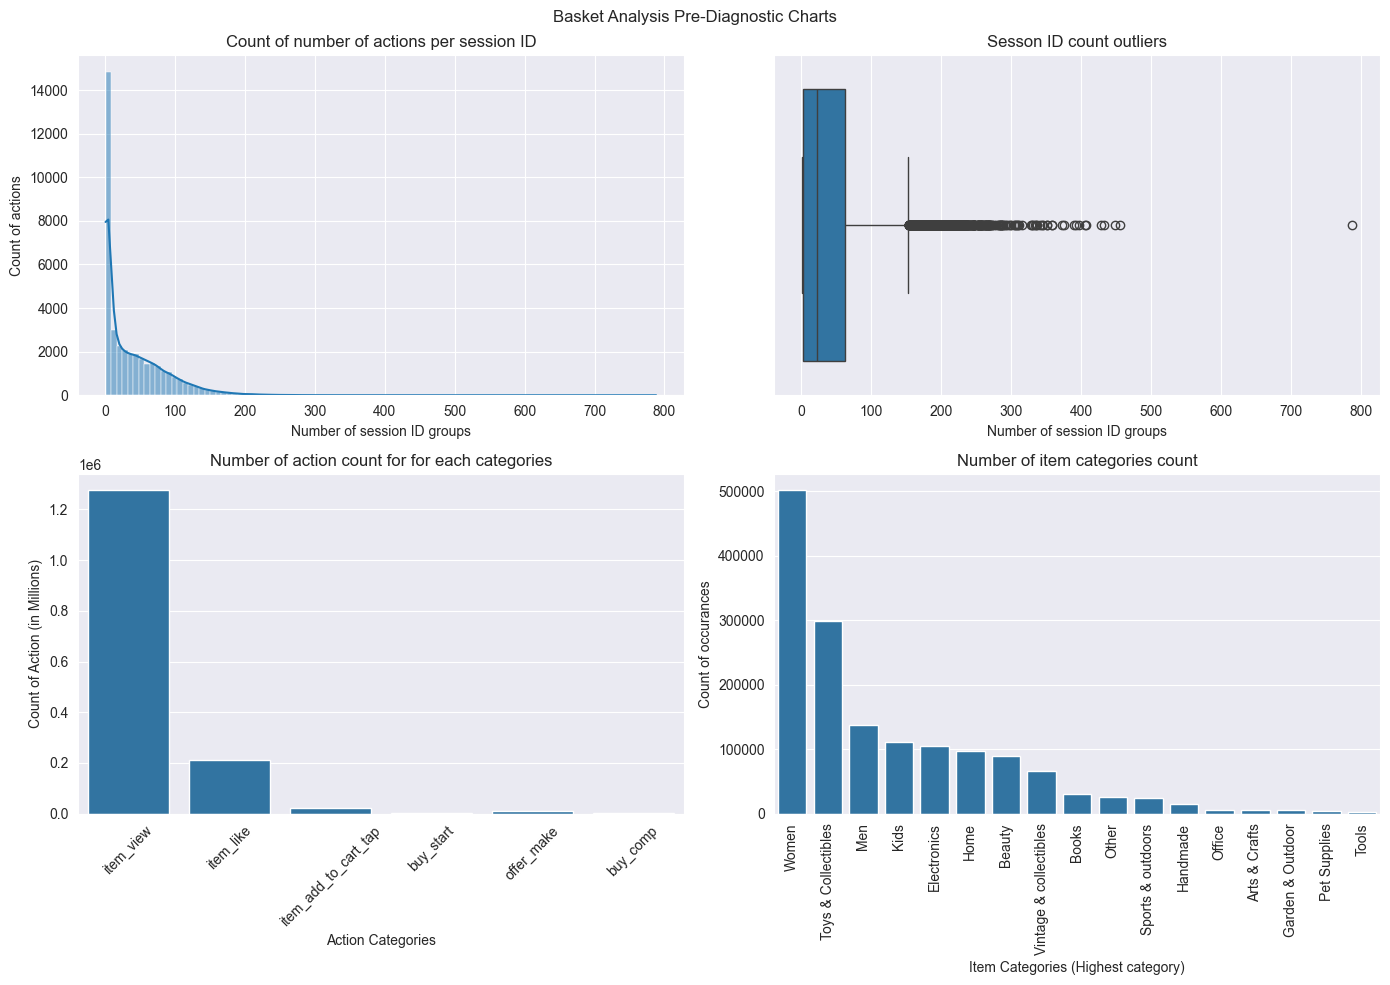

In [7]:
# Data diagnostic

# Basket Analysis
sess_id_group = df['session_id'].value_counts()
event_count = pd.DataFrame(df['event_id'].value_counts()).reset_index()
cat_count = pd.DataFrame(df['c0_name'].value_counts()).reset_index()

fig, axes = plt.subplots(2,2,figsize=[14,10])
fig.suptitle('Basket Analysis Pre-Diagnostic Charts')

sns.histplot(sess_id_group, bins=100, ax=axes[0,0], kde=True)
axes[0,0].set_title('Count of number of actions per session ID')
axes[0,0].set_xlabel('Number of session ID groups')
axes[0,0].set_ylabel('Count of actions')

sns.boxplot(x=sess_id_group, ax=axes[0,1])
axes[0,1].set_title('Sesson ID count outliers')
axes[0,1].set_xlabel('Number of session ID groups')

sns.barplot(x='event_id', y='count', data=event_count, ax=axes[1,0])
axes[1,0].set_xlabel('Action Categories')
axes[1,0].set_ylabel('Count of Action (in Millions)')
axes[1,0].set_title('Number of action count for for each categories')
plt.setp(axes[1,0].get_xticklabels(), rotation=45)

sns.barplot(x='c0_name', y='count', data=cat_count, ax=axes[1,1])
axes[1,1].set_xlabel('Item Categories (Highest category)')
axes[1,1].set_ylabel('Count of occurances')
axes[1,1].set_title('Number of item categories count')
plt.setp(axes[1,1].get_xticklabels(), rotation=90)

plt.tight_layout()
plt.show()

In [8]:
print('\nEvent Count \n')
event_count


Event Count 



,event_id,count
0,item_view,1275699
1,item_like,213684
2,item_add_to_cart_tap,22692
3,offer_make,9747
4,buy_start,2413
5,buy_comp,1504


In [9]:
print('\nCategory Count \n')
cat_count


Category Count 



,c0_name,count
0,Women,501621
1,Toys & Collectibles,299016
2,Men,137255
3,Kids,111905
4,Electronics,104746
5,Home,97654
6,Beauty,88710
7,Vintage & collectibles,65872
8,Books,30073
9,Other,26320


In [10]:
# Duplicated Items
print("Number of unique: ",df['name'].nunique())
print("Number of duplicates: ",(df.shape[0] - df['name'].nunique()))

Number of unique:  1132857
Number of duplicates:  392882


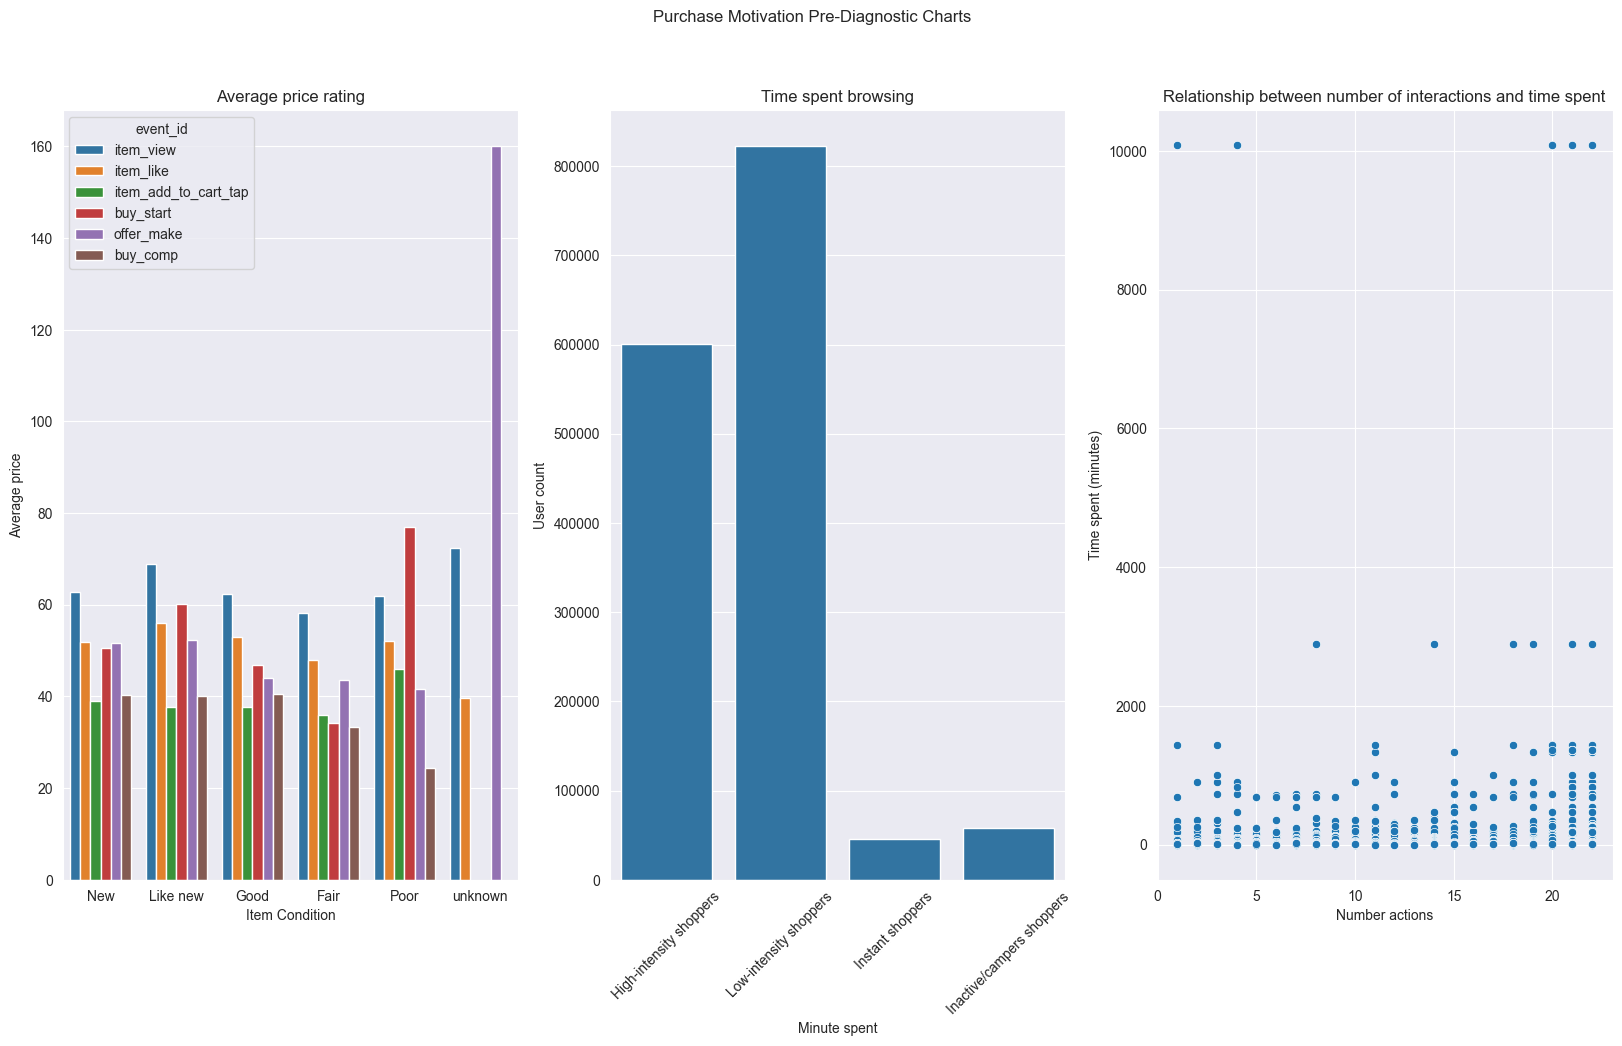

In [19]:
# Data diagnostic
'''
    data in pre-diagnostic are mostly categorized, in ML modeling data transformation will be done
    As reporting categorized data will introduce bias
'''

# Purchase Motivation
avg_price_cat_nested = pd.DataFrame(df.groupby(['item_condition_name','event_id'])['price'].agg(['mean','std'])).reset_index()

fig, axes = plt.subplots(1, 3, figsize=[20,10])
fig.suptitle('Purchase Motivation Pre-Diagnostic Charts')

sns.barplot(x='item_condition_name', y='mean', data=avg_price_cat_nested, ax=axes[0], hue='event_id')
axes[0].set_title('Average price rating')
axes[0].set_xlabel('Item Condition')
axes[0].set_ylabel('Average price')

sns.countplot(df,x='shopper_category', ax=axes[1])
axes[1].set_title('Time spent browsing')
axes[1].set_xlabel('Minute spent')
axes[1].set_ylabel('User count')
plt.setp(axes[1].get_xticklabels(), rotation=45)

sns.scatterplot(x='sequence_length',y='session_length_min', data=df, ax=axes[2])
axes[2].set_title('Relationship between number of interactions and time spent')
axes[2].set_xlabel('Number actions')
axes[2].set_ylabel('Time spent (minutes)')

plt.show()

In [12]:
print('\nAverage price per item condition (Table)')
avg_price_cat_nested


Average price per item condition (Table)


,item_condition_name,event_id,mean,std
0,New,item_view,62.687022,128.720292
1,New,item_like,51.877704,97.472839
2,New,item_add_to_cart_tap,38.913548,81.943264
3,New,buy_start,50.476129,83.706543
4,New,offer_make,51.573813,81.226560
5,New,buy_comp,40.404667,58.932147
6,Like new,item_view,68.921545,161.458412
7,Like new,item_like,55.936365,132.896899
8,Like new,item_add_to_cart_tap,37.689806,78.368323
9,Like new,buy_start,60.176458,178.549562
